In [3]:
!pip install numpy pandas seaborn matplotlib scikit-learn 

In [4]:
# libraries
import numpy as np
import pandas as pd
import random
import seaborn as sns
sns.set(style="ticks", color_codes=True)
from sklearn import neighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis


In [5]:
#Columns/Features
D = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
L = 'quality'
C = 'color'
DL = D + [L]
DC = D + [C]
DLC = DL + [C]

#Loading Data set
wine_r = pd.read_csv("datasets/wine_quality/winequality-red.csv", sep=';')
#Loading Data set
wine_w = pd.read_csv("datasets/wine_quality/winequality-white.csv", sep=';')

# Checking for missing values
print("\nmissing values in red wine dataset: ", wine_r.isnull().sum())
print("\nmissing values in white wine dataset: ", wine_w.isnull().sum())

wine_w= wine_w.copy()
wine_w[C]= np.zeros(wine_w.shape[0])
wine_r[C]= np.ones(wine_r.shape[0])
wine = pd.concat([wine_w,wine_r])


missing values in red wine dataset:  fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

missing values in white wine dataset:  fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [6]:
print(f'Data: shape={wine[DL].shape}')
display(wine[DL].describe())
display(wine[DL].head())

Data: shape=(6497, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [7]:
wine[C]

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
1594    1.0
1595    1.0
1596    1.0
1597    1.0
1598    1.0
Name: color, Length: 6497, dtype: float64

In [8]:
# Compute summary statistics for all columns in wine data
summary = pd.DataFrame(index=wine.columns, columns=['mean', 'median', 'variance', 'skewness', 'kurtosis'])
for col in wine.columns:
    summary.loc[col, 'mean'] = wine[col].mean()
    summary.loc[col, 'median'] = wine[col].median()
    summary.loc[col, 'variance'] = wine[col].var()
    summary.loc[col, 'skewness'] = skew(wine[col])
    summary.loc[col, 'kurtosis'] = kurtosis(wine[col])
print("\nSummary Statistics for all columns in wine data:")
print(summary)


Summary Statistics for all columns in wine data:
                            mean   median     variance  skewness   kurtosis
fixed acidity           7.215307      7.0      1.68074  1.722892   5.056343
volatile acidity        0.339666     0.29     0.027105  1.494751   2.822275
citric acid             0.318633     0.31     0.021117  0.471622   2.394471
residual sugar          5.443235      3.0    22.636696  1.435073   4.354994
chlorides               0.056034    0.047     0.001227  5.398581  50.857966
free sulfur dioxide    30.525319     29.0   315.041192  1.219784   7.899231
total sulfur dioxide  115.744574    118.0  3194.720039 -0.001177  -0.372301
density                 0.994697  0.99489     0.000009  0.503485   6.600061
pH                      3.218501     3.21     0.025853  0.386749   0.366451
sulphates               0.531268     0.51     0.022143  1.796855   8.646117
alcohol                10.491801     10.3     1.422561  0.565587  -0.532202
quality                 5.818378      

In [9]:
print(f'Labels: shape={wine[C].shape}')
display(wine[C].describe())
display(wine[C].head())

Labels: shape=(6497,)


count    6497.000000
mean        0.246114
std         0.430779
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: color, dtype: float64

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: color, dtype: float64

In [10]:
# Apply z-score normalization to all columns in wine data except target 'quality'

features = wine[DC].columns
wine_normalized = wine.copy()
wine_normalized[features] = (wine[features] - wine[features].mean()) / wine[features].std()

print("normalised wine data: \n")
print(wine_normalized.head())

normalised wine data: 

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0      -0.166076         -0.423150     0.284664        3.206682  -0.314951   
1      -0.706019         -0.240931     0.147035       -0.807775  -0.200775   
2       0.682405         -0.362411     0.559923        0.306184  -0.172231   
3      -0.011807         -0.666110     0.009405        0.642474   0.056121   
4      -0.011807         -0.666110     0.009405        0.642474   0.056121   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0             0.815503              0.959902  2.102052 -1.358944  -0.546136   
1            -0.931035              0.287595 -0.232314  0.506876  -0.277330   
2            -0.029596             -0.331634  0.134515  0.258100  -0.613338   
3             0.928182              1.242978  0.301255 -0.177258  -0.882144   
4             0.928182              1.242978  0.301255 -0.177258  -0.882144   

    alcohol  quality     color  

In [11]:
# Create Train/Test Split
ran = 42
train_size = .8
#features are in [D], color is in [C], labels are in [L], we use [DC] for training features.
X_wine = wine_normalized[DC]
y_wine = wine_normalized[L]
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(X_wine, y_wine, train_size=train_size, random_state = ran) 
print("xtrain\n",X_wine_train)
print("xtest\n",X_wine_test)
print("ytrain\n",y_wine_train) 
print("ytest\n",y_wine_test)

xtrain
       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1916      -0.474615         -0.544630     0.284664        0.558401  -0.314951   
947        0.990944         -1.091289     0.215849       -0.807775  -0.486215   
877       -0.937423         -0.362411     0.147035       -0.807775   1.797307   
2927      -0.166076         -0.180191    -0.059409        0.768582  -0.571847   
1165       0.990944          0.609428     1.248069       -0.744721   8.933313   
...             ...               ...          ...             ...        ...   
3772      -0.706019         -0.605370    -0.197039        1.735415  -0.600391   
293       -0.243211          0.123508    -0.472297       -0.639630   1.197883   
328        4.770543         -0.423150     2.073845       -0.597594   0.741178   
492        1.299482          0.366468     1.316884       -0.597594  -0.115143   
860        0.682405         -0.423150     0.215849       -0.786757  -0.743111   

      free sulfur d

## Regression Task

### **Wine dataset**

In [12]:
# setup 5-fold cross-validation
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

cross_val = KFold(n_splits=5, shuffle=True, random_state=ran)

#### KNN Regression

In [13]:
## KNN with 5-fold cross validation to find best k parameter
k_values = range(1, 30)
wine_rmse_scores = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    current_scores = cross_val_score(knn, X_wine_train, y_wine_train, cv=cross_val, scoring='neg_root_mean_squared_error')  ## 5 fold cross validation
    wine_rmse_scores.append(-current_scores.mean())

## Best k parameter
best_wine_k_knn = k_values[np.argmin(wine_rmse_scores)]
print('Best k parameter:', best_wine_k_knn)

Best k parameter: 8


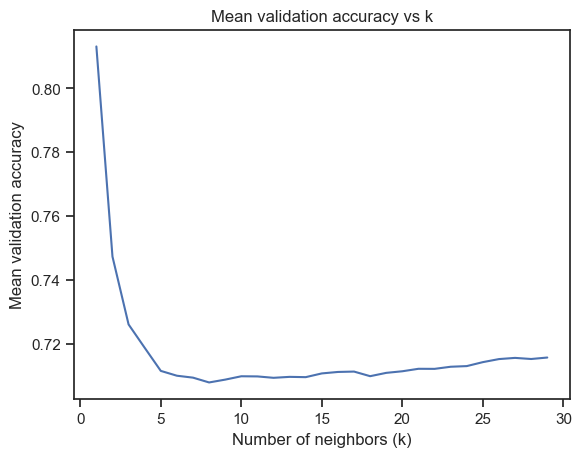

In [15]:
plt.plot(k_values, wine_rmse_scores,)
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Mean validation accuracy')
plt.title('Mean validation accuracy vs k')
plt.show()

In [16]:
## Retraining KNN with best k parameter
wine_best_knn = KNeighborsRegressor(n_neighbors=best_wine_k_knn)
wine_best_knn.fit(X_wine_train, y_wine_train)

## Calculate RMSE on Test set
wine_y_pred = wine_best_knn.predict(X_wine_test)
wine_test_knn_rmse = np.sqrt(mean_squared_error(y_wine_test, wine_y_pred))
print(f'Test RMSE with best k value of {best_wine_k_knn}: {wine_test_knn_rmse:.4f}')

Test RMSE with best k value of 8: 0.6711


In [ ]:
## Retaining weighted KNN using distance
wine_knn_weighted = KNeighborsRegressor(n_neighbors=best_wine_k_knn, weights='distance')
wine_knn_weighted.fit(X_wine_train, y_wine_train)

## Calculate accuracy on Test set
wine_weighted_y_pred = wine_knn_weighted.predict(X_wine_test)
wine_test_weighted_knn_rmse = np.sqrt(mean_squared_error(y_wine_test, wine_weighted_y_pred))
print(f'Test RMSE with weighted KNN using distance with best k value of {best_wine_k_knn}: {wine_test_weighted_knn_rmse:.4f}')

Test RMSE with weighted KNN using distance with best k value of 8: 0.5944


#### DT Regression

In [52]:
from sklearn.tree import DecisionTreeRegressor
decision_tree = DecisionTreeRegressor()
param_grid = {'max_depth': range(1, 30)}

wine_grid_search = GridSearchCV(decision_tree, param_grid, cv=cross_val, scoring='neg_root_mean_squared_error')
wine_grid_search.fit(X_wine_train, y_wine_train)

## Best max_depth parameter
best_wine_depth_decisiontree = wine_grid_search.best_params_['max_depth']
best_wine_rmse_dt = -wine_grid_search.best_score_
print(f'Best tree depth parameter: {best_wine_depth_decisiontree}')
print(f'Best RMSE with tree depth of {best_wine_depth_decisiontree}: {best_wine_rmse_dt:.4f}')

Best tree depth parameter: 5
Best RMSE with tree depth of 5: 0.7466


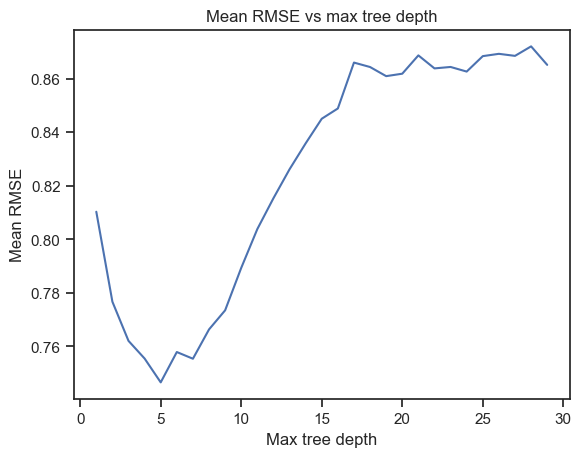

In [54]:
max_depths = range(1, 30)
wine_mean_rmse = -wine_grid_search.cv_results_['mean_test_score']

plt.plot(max_depths, wine_mean_rmse)
plt.xlabel('Max tree depth')
plt.ylabel('Mean RMSE')
plt.title('Mean RMSE vs max tree depth')
plt.show()

In [20]:
# using best max_depth parameter to retrain the DT model
wine_final_tree = DecisionTreeRegressor(max_depth=best_wine_depth_decisiontree)
wine_final_tree.fit(X_wine_train, y_wine_train)

wine_y_pred = wine_final_tree.predict(X_wine_test)
wine_test_decision_rmse = np.sqrt(mean_squared_error(y_wine_test, wine_y_pred))
print(f'Test RMSE: {wine_test_decision_rmse:.4f}')

Test RMSE: 0.6881


#### Random Forest Regression


In [57]:
from sklearn.ensemble import RandomForestRegressor
param_grid = {'n_estimators': range(1, 30), 'max_depth': range(1, 30)}

wine_grid_search_rf = GridSearchCV(RandomForestRegressor(), param_grid, cv=cross_val, scoring='neg_root_mean_squared_error',n_jobs=-1)
wine_grid_search_rf.fit(X_wine_train, y_wine_train)

results = pd.DataFrame(wine_grid_search_rf.cv_results_)

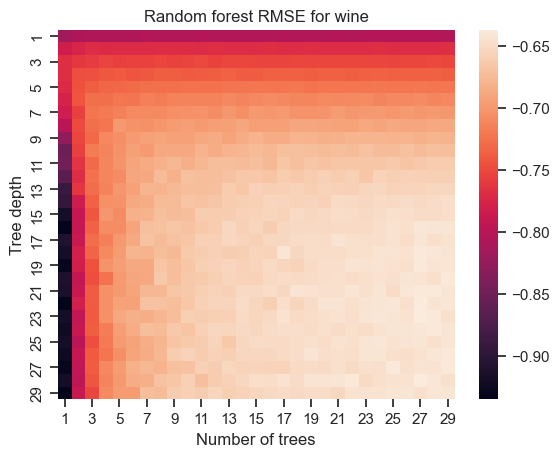

Best tree depth: 23
Best number of trees: 27
Best RMSE: 0.6368378253942799


In [58]:
heat_map_data = results.pivot(index='param_max_depth', columns='param_n_estimators', values='mean_test_score')

sns.heatmap(heat_map_data)
plt.title('Random forest RMSE for wine')
plt.xlabel('Number of trees')
plt.ylabel('Tree depth')
plt.show()

## Best parameters
best_wine_depth_forest = wine_grid_search_rf.best_params_['max_depth']
best_wine_n_estimators_forest = wine_grid_search_rf.best_params_['n_estimators']
best_wine_rmse_rf = -wine_grid_search_rf.best_score_
print('Best tree depth:', best_wine_depth_forest)
print('Best number of trees:', best_wine_n_estimators_forest)
print('Best RMSE:', best_wine_rmse_rf)

In [23]:
# retrain the model with best parameters
wine_final_forest = RandomForestRegressor(max_depth=best_wine_depth_forest, n_estimators=best_wine_n_estimators_forest)
wine_final_forest.fit(X_wine_train, y_wine_train)

wine_y_pred = wine_final_forest.predict(X_wine_test)
wine_test_forest_rmse = np.sqrt(mean_squared_error(y_wine_test, wine_y_pred))
print(f'Test RMSE: {wine_test_forest_rmse:.4f}')

Test RMSE: 0.5746


#### Gradient Tree Boosting

In [24]:
from sklearn.ensemble import GradientBoostingRegressor
param_grid = {'n_estimators': range(1, 30), 'max_depth': range(1, 30)}
wine_grid_search_boost = GridSearchCV(GradientBoostingRegressor(), param_grid, cv=cross_val, scoring='neg_root_mean_squared_error', n_jobs=-1)
wine_grid_search_boost.fit(X_wine_train, y_wine_train)

results = pd.DataFrame(wine_grid_search_boost.cv_results_)

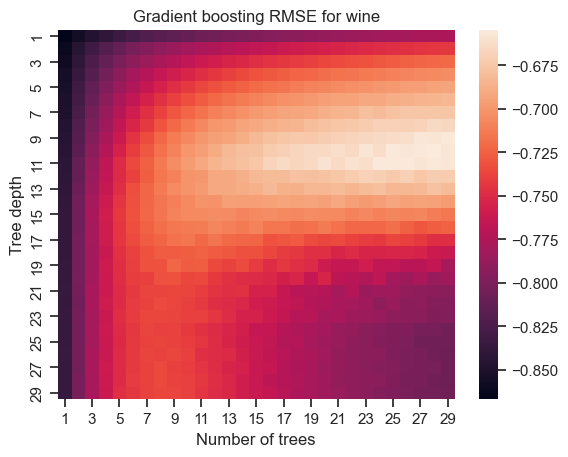

Best tree depth: 10
Best number of trees: 28
Best RMSE: 0.6544062350313752


In [ ]:
heat_map_data = results.pivot(index='param_max_depth', columns='param_n_estimators', values='mean_test_score')

sns.heatmap(heat_map_data)
plt.title('Gradient boosting RMSE for wine')
plt.xlabel('Number of trees')
plt.ylabel('Tree depth')
plt.show()

## Best parameters
best_wine_depth_boost = wine_grid_search_boost.best_params_['max_depth']
best_wine_n_estimators_boost = wine_grid_search_boost.best_params_['n_estimators']
best_wine_rmse_boost = -wine_grid_search_boost.best_score_
print('Best tree depth:', best_wine_depth_boost)
print('Best number of trees:', best_wine_n_estimators_boost)
print('Best RMSE:', best_wine_rmse_boost)


In [26]:
# using best parameters to retrain the gradient tree boosting model
wine_final_boost = GradientBoostingRegressor(max_depth=best_wine_depth_boost, n_estimators=best_wine_n_estimators_boost)
wine_final_boost.fit(X_wine_train, y_wine_train)

wine_y_pred = wine_final_boost.predict(X_wine_test)
wine_test_boost_rmse = np.sqrt(mean_squared_error(y_wine_test, wine_y_pred))
print(f'Test RMSE: {wine_test_boost_rmse:.4f}')


Test RMSE: 0.5923


In [27]:
# Presenting the results for all models for wine dataset sorted from lowest to highest
results = pd.DataFrame({
    'Model': ['KNN', 'Weighted KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Test RMSE': [wine_test_knn_rmse, wine_test_weighted_knn_rmse, wine_test_decision_rmse, wine_test_forest_rmse, wine_test_boost_rmse]
})
results = results.sort_values(by='Test RMSE')
results

,Model,Test RMSE
3,Random Forest,0.574611
4,Gradient Boosting,0.592278
1,Weighted KNN,0.594374
0,KNN,0.671071
2,Decision Tree,0.688087


### Model choice and conclusion
From the above training algorithms, the model produced by Random Forest has the best performance when evaluated with Root Mean Square Error as the performance metric as it has the lowest Root Mean Square Error value.

### **Abalone Dataset**


In [28]:
## Loading abalone dataset
header = ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight',  'Rings']
abalone = pd.read_csv('datasets/abalone/abalone.csv', names=header, header=None)
abalone

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [29]:
# checking for missing data
print(abalone.isnull().sum())

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64


In [ ]:
abalone_numerical_features = abalone.select_dtypes(include=np.number).columns
summary = pd.DataFrame(index=abalone_numerical_features, columns=['mean', 'median', 'variance', 'skewness', 'kurtosis'])

for col in abalone_numerical_features:
    summary.loc[col, 'mean'] = abalone[col].mean()
    summary.loc[col, 'median'] = abalone[col].median()
    summary.loc[col, 'variance'] = abalone[col].var()
    summary.loc[col, 'skewness'] = skew(abalone[col])
    summary.loc[col, 'kurtosis'] = kurtosis(abalone[col])

print("Summarization statistics for abalones")
print(summary)

Summarization statistics for abalones
                    mean  median   variance  skewness   kurtosis
Length          0.523992   0.545   0.014422 -0.639643   0.063108
Diameter        0.407881   0.425   0.009849 -0.608979  -0.046857
Height          0.139516    0.14    0.00175  3.127694  75.933099
Whole weight    0.828742  0.7995   0.240481  0.530768  -0.025051
Shucked weight  0.359367   0.336   0.049268   0.71884   0.592975
Viscera weight  0.180594   0.171   0.012015   0.59164   0.082475
Shell weight    0.238831   0.234   0.019377  0.620704   0.529854
Rings           9.933684     9.0  10.395266  1.113702   2.326462


In [31]:
class_counts = abalone["Rings"].value_counts()
print("Class distribution:")
print(class_counts)

Class distribution:
Rings
9     689
10    634
8     568
11    487
7     391
12    267
6     259
13    203
14    126
5     115
15    103
16     67
17     58
4      57
18     42
19     32
20     26
3      15
21     14
23      9
22      6
27      2
24      2
1       1
26      1
29      1
2       1
25      1
Name: count, dtype: int64


From assignment 1:   
I feel that this dataset is imbalanced because the rings have a skewed distribution, with most samples lying in the 8-12 rings range, and few in the extreme ends (<4 rings and >18 rings). This could result in the model predicting the 8-12 rings range accurately, while having unreliable predictions for extremely young and old abalones. We could remove data that has very little sample size for each ring value, for example 25 rings and 1 ring, where the sample size is only 1.

In [41]:
## Correction by removing classes with sample size less than 5
small_rings_sample = [27, 24, 1, 26, 29, 2, 25]

abalone = abalone[abalone['Rings'].apply(lambda x: x not in small_rings_sample)]

In [42]:
abalone_numerical_features = abalone.drop(columns=['Rings']).select_dtypes(include=['number']).columns  ## exclude 'Sex'
abalone_normalised = abalone.copy()

## Z-score normalization
abalone_normalised[abalone_numerical_features] = (abalone[abalone_numerical_features] - abalone[abalone_numerical_features].mean()) / abalone[abalone_numerical_features].std()
abalone_normalised

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,-0.576013,-0.432992,-1.066323,-0.641379,-0.607323,-0.725797,-0.638474,15
1,M,-1.452836,-1.443496,-1.186206,-1.231000,-1.170779,-1.205083,-1.216430,7
2,F,0.050288,0.122785,-0.107256,-0.308248,-0.463078,-0.356062,-0.205008,9
3,M,-0.701274,-0.432992,-0.347023,-0.637292,-0.647892,-0.607117,-0.602352,10
4,I,-1.619850,-1.544546,-1.425972,-1.272897,-1.215855,-1.287247,-1.324797,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.342563,0.425937,0.612043,0.120939,0.048539,0.534041,0.076746,11
4173,M,0.551330,0.324886,-0.107256,0.282395,0.359567,0.310374,0.159827,10
4174,M,0.634837,0.678563,1.571109,0.711582,0.749478,0.976810,0.502988,9
4175,F,0.843604,0.779613,0.252393,0.545016,0.774270,0.734885,0.416295,10


In [43]:
# map ordinal values (sex) to numerical values
sex_map = {'M': 0, 'F': 1, 'I': 2}
abalone_normalised['Sex'] = abalone_normalised['Sex'].map(sex_map)

In [44]:
## Predict rings of abalone with all features
X_abalone = abalone_normalised.drop(columns=['Rings'])  ## Features
y_abalone = abalone_normalised['Rings']  ## Target

## 80%-20% training, test split
abalone_X_train, abalone_X_test, abalone_y_train, abalone_y_test = train_test_split(X_abalone, y_abalone, test_size=0.2, train_size=0.8)

#### KNN Regression

In [45]:
## KNN with 5-fold cross validation to find best k parameter
cross_val = KFold(n_splits=5, shuffle=True, random_state=ran)

k_values = range(1, 50)
abalone_rmse_scores = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    current_scores = cross_val_score(knn, abalone_X_train, abalone_y_train, cv=cross_val, scoring='neg_root_mean_squared_error')  ## 5 fold cross validation
    abalone_rmse_scores.append(-current_scores.mean())

## Best k parameter
best_abalone_k_knn = k_values[np.argmin(abalone_rmse_scores)]
print('Best k parameter:', best_abalone_k_knn)

Best k parameter: 12


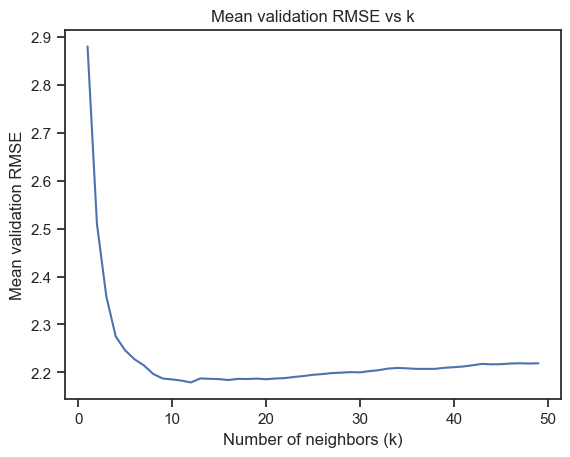

In [46]:
plt.plot(k_values, abalone_rmse_scores,)
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Mean validation RMSE')
plt.title('Mean validation RMSE vs k')
plt.show()

In [48]:
## Retraining KNN with best k parameter
abalone_best_knn = KNeighborsRegressor(n_neighbors=best_abalone_k_knn)
abalone_best_knn.fit(abalone_X_train, abalone_y_train)

## Calculate RMSE on Test set
abalone_y_pred = abalone_best_knn.predict(abalone_X_test)
abalone_test_knn_rmse = np.sqrt(mean_squared_error(abalone_y_test, abalone_y_pred))
print(f'Test RMSE with best k value of {best_abalone_k_knn}: {abalone_test_knn_rmse:.4f}')

Test RMSE with best k value of 12: 2.2079


In [49]:
## Retaining weighted KNN using distance
abalone_knn_weighted = KNeighborsRegressor(n_neighbors=best_abalone_k_knn, weights='distance')
abalone_knn_weighted.fit(abalone_X_train, abalone_y_train)

## Calculate accuracy on Test set
abalone_weighted_y_pred = abalone_knn_weighted.predict(abalone_X_test)
abalone_test_weighted_knn_rmse = np.sqrt(mean_squared_error(abalone_y_test, abalone_weighted_y_pred))
print(f'Test RMSE with weighted KNN using distance with best k value of {best_abalone_k_knn}: {abalone_test_weighted_knn_rmse:.4f}')


Test RMSE with weighted KNN using distance with best k value of 12: 2.1995


#### DT Regression


In [50]:
from sklearn.tree import DecisionTreeRegressor
decision_tree = DecisionTreeRegressor()
param_grid = {'max_depth': range(1, 30)}

abalone_grid_search = GridSearchCV(decision_tree, param_grid, cv=cross_val, scoring='neg_root_mean_squared_error')
abalone_grid_search.fit(abalone_X_train, abalone_y_train)

## Best max_depth parameter
best_abalone_depth_decisiontree = abalone_grid_search.best_params_['max_depth']
best_abalone_rmse_dt = -abalone_grid_search.best_score_
print(f'Best tree depth parameter: {best_abalone_depth_decisiontree}')
print(f'Best RMSE with tree depth of {best_abalone_depth_decisiontree}: {best_abalone_rmse_dt:.4f}')


Best tree depth parameter: 5
Best RMSE with tree depth of 5: 2.2749


Text(0.5, 1.0, 'Mean RMSE vs max tree depth')

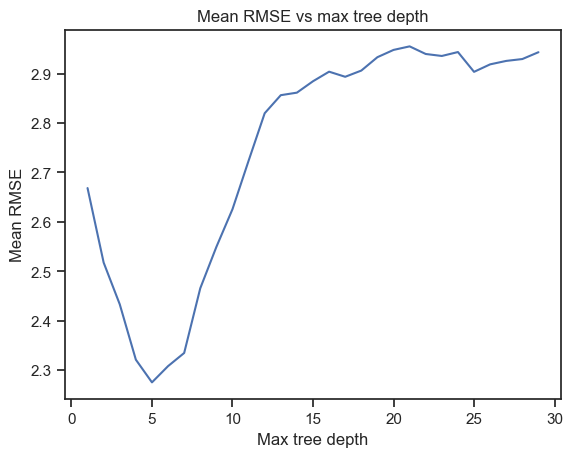

In [55]:
max_depths = range(1, 30)
abalone_mean_rmse = -abalone_grid_search.cv_results_['mean_test_score']

plt.plot(max_depths, abalone_mean_rmse)
plt.xlabel('Max tree depth')
plt.ylabel('Mean RMSE')
plt.title('Mean RMSE vs max tree depth')

In [56]:
# using best max_depth parameter to retrain the DT model
abalone_final_tree = DecisionTreeRegressor(max_depth=best_abalone_depth_decisiontree)
abalone_final_tree.fit(abalone_X_train, abalone_y_train)

abalone_y_pred = abalone_final_tree.predict(abalone_X_test)
abalone_test_decision_rmse = np.sqrt(mean_squared_error(abalone_y_test, abalone_y_pred))
print(f'Test RMSE: {abalone_test_decision_rmse:.4f}')

Test RMSE: 2.3538


#### Random Forest Regression

In [59]:
param_grid = {'n_estimators': range(1, 30), 'max_depth': range(1, 30)}

abalone_grid_search_rf = GridSearchCV(RandomForestRegressor(), param_grid, cv=cross_val, scoring='neg_root_mean_squared_error',n_jobs=-1)
abalone_grid_search_rf.fit(abalone_X_train, abalone_y_train)

results = pd.DataFrame(abalone_grid_search_rf.cv_results_)

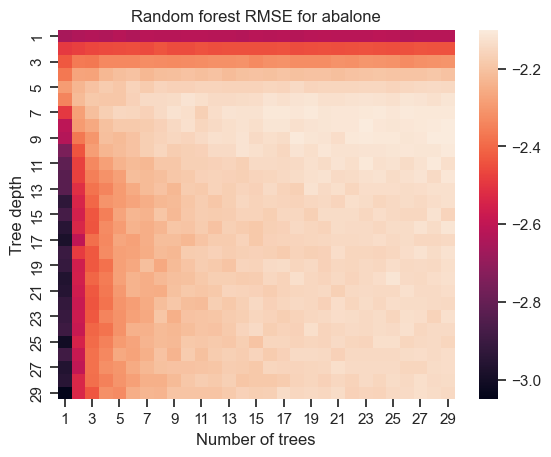

Best tree depth: 9
Best number of trees: 28
Best RMSE: 2.0998474831062364


In [60]:
heat_map_data = results.pivot(index='param_max_depth', columns='param_n_estimators', values='mean_test_score')

sns.heatmap(heat_map_data)
plt.title('Random forest RMSE for abalone')
plt.xlabel('Number of trees')
plt.ylabel('Tree depth')
plt.show()

# Best parameters
best_abalone_depth_forest = abalone_grid_search_rf.best_params_['max_depth']
best_abalone_n_estimators_forest = abalone_grid_search_rf.best_params_['n_estimators']
best_abalone_rmse_rf = -abalone_grid_search_rf.best_score_
print('Best tree depth:', best_abalone_depth_forest)
print('Best number of trees:', best_abalone_n_estimators_forest)
print('Best RMSE:', best_abalone_rmse_rf)

In [66]:
# retraining the model with best parameters
abalone_final_forest = RandomForestRegressor(max_depth=best_abalone_depth_forest, n_estimators=best_abalone_n_estimators_forest)
abalone_final_forest.fit(abalone_X_train, abalone_y_train)

abalone_y_pred = abalone_final_forest.predict(abalone_X_test)
abalone_test_forest_rmse = np.sqrt(mean_squared_error(abalone_y_test, abalone_y_pred))
print(f'Test RMSE: {abalone_test_forest_rmse:.4f}')


Test RMSE: 2.1837


#### Gradient Tree Boosting

In [69]:
param_grid = {'n_estimators': range(1, 30), 'max_depth': range(1, 30)}
abalone_grid_search_boost = GridSearchCV(GradientBoostingRegressor(), param_grid, cv=cross_val, scoring='neg_root_mean_squared_error', n_jobs=-1)
abalone_grid_search_boost.fit(abalone_X_train, abalone_y_train)

results = pd.DataFrame(abalone_grid_search_boost.cv_results_)

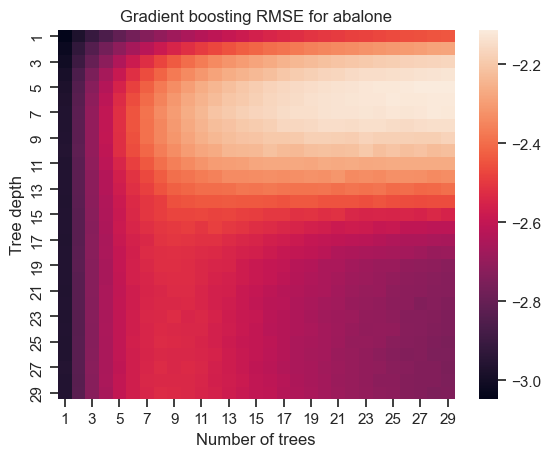

Best tree depth: 5
Best number of trees: 28
Best RMSE: 2.1118412982266515


In [70]:
heat_map_data = results.pivot(index='param_max_depth', columns='param_n_estimators', values='mean_test_score')

sns.heatmap(heat_map_data)
plt.title('Gradient boosting RMSE for abalone')
plt.xlabel('Number of trees')
plt.ylabel('Tree depth')
plt.show()

## Best parameters
best_abalone_depth_boost = abalone_grid_search_boost.best_params_['max_depth']
best_abalone_n_estimators_boost = abalone_grid_search_boost.best_params_['n_estimators']
best_abalone_rmse_boost = -abalone_grid_search_boost.best_score_
print('Best tree depth:', best_abalone_depth_boost)
print('Best number of trees:', best_abalone_n_estimators_boost)
print('Best RMSE:', best_abalone_rmse_boost)

In [72]:
# using best parameters to retrain the gradient tree boosting model
abalone_final_boost = GradientBoostingRegressor(max_depth=best_abalone_depth_boost, n_estimators=best_abalone_n_estimators_boost)
abalone_final_boost.fit(abalone_X_train, abalone_y_train)

abalone_y_pred = abalone_final_boost.predict(abalone_X_test)
abalone_test_boost_rmse = np.sqrt(mean_squared_error(abalone_y_test, abalone_y_pred))
print(f'Test RMSE: {abalone_test_boost_rmse:.4f}')


Test RMSE: 2.1777


In [73]:
# Presenting the results for all models for abalone dataset sorted from lowest to highest
results = pd.DataFrame({
    'Model': ['KNN', 'Weighted KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Test RMSE': [abalone_test_knn_rmse, abalone_test_weighted_knn_rmse, abalone_test_decision_rmse, abalone_test_forest_rmse, abalone_test_boost_rmse]
})
results = results.sort_values(by='Test RMSE')
results

,Model,Test RMSE
4,Gradient Boosting,2.177687
3,Random Forest,2.183688
1,Weighted KNN,2.199531
0,KNN,2.207869
2,Decision Tree,2.353830


### Model choice and conclusion
From the above training algorithms, the model produced by gradient tree boosting has the best performance when evaluated with Root Mean Square Error as the performance metric as it has the lowest Root Mean Square Error value.  
That being said, the Root Mean Square Error of 2.177 is considerably high, which might indicate that the models is unable to find a optimal solution to the regression problem. This might indicate that there is either little to no correlation between the Rings on the Abalone and the other features input into the regression.  


### **Forest FIres Dataset**

In [85]:
## Loading Forest Fires dataset
header = ['X','Y','month','day','FFMC','DMC','DC','ISI','temp','RH','wind','rain','area']
forest_fires = pd.read_csv('datasets/forest_fires/forestfires.csv', names=header, header=None,skiprows=1)
forest_fires

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


In [86]:
# checking for missing data
print(forest_fires.isnull().sum())

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64


In [87]:
forest_fires_numerical_features= forest_fires.select_dtypes(include=np.number).columns
summary = pd.DataFrame(index=forest_fires_numerical_features, columns=['mean', 'median', 'variance', 'skewness', 'kurtosis'])

for col in forest_fires_numerical_features:
    summary.loc[col, 'mean'] = forest_fires[col].mean()
    summary.loc[col, 'median'] = forest_fires[col].median()
    summary.loc[col, 'variance'] = forest_fires[col].var()
    summary.loc[col, 'skewness'] = skew(forest_fires[col])
    summary.loc[col, 'kurtosis'] = kurtosis(forest_fires[col])

print("Summarization statistics for forest fires")
print(summary)

Summarization statistics for forest fires
            mean median      variance   skewness    kurtosis
X       4.669246    4.0      5.353568   0.036141   -1.172607
Y       4.299807    4.0      1.512655   0.416085    1.395269
FFMC   90.644681   91.6     30.471624  -6.556512   66.407604
DMC    110.87234  108.3   4101.951889   0.545908    0.191263
DC    547.940039  664.2  61536.835467   -1.09725   -0.254461
ISI     9.021663    8.4     20.788832   2.528961    21.23949
temp   18.889168   19.3     33.716898  -0.330211    0.123269
RH     44.288201   42.0    266.259802   0.860398    0.422374
wind    4.017602    4.0      3.210019   0.569343    0.042217
rain    0.021663    0.0      0.087592  19.758803   417.22097
area   12.847292   0.52   4052.063225   12.80963  192.256646


In [88]:
class_counts = forest_fires["area"].value_counts()
print("Class distribution:")
print(class_counts)

Class distribution:
area
0.00      247
1.94        3
0.52        2
3.71        2
0.68        2
         ... 
105.66      1
154.88      1
196.48      1
200.94      1
11.16       1
Name: count, Length: 251, dtype: int64


In [90]:
# transforming the target variable 'area' to log scale
forest_fires['log_area'] = np.log1p(forest_fires['area'])

forest_fires_categorical_features = ['month', 'day']
forest_fires_numerical_features = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']

## One-hot encoding for categorical features
forest_fires_encoded = pd.get_dummies(forest_fires, columns=forest_fires_categorical_features)

## Z-score normalization
forest_fires_normalised = forest_fires_encoded.copy()
forest_fires_normalised[forest_fires_numerical_features] = (forest_fires_encoded[forest_fires_numerical_features] - forest_fires_encoded[forest_fires_numerical_features].mean()) / forest_fires_encoded[forest_fires_numerical_features].std()
forest_fires_normalised

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,month_nov,month_oct,month_sep,day_fri,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,1.007337,0.569309,-0.805180,-1.322045,-1.828706,-0.860113,-1.840857,0.411326,1.497164,-0.073197,...,False,False,False,True,False,False,False,False,False,False
1,1.007337,-0.243765,-0.008094,-1.178399,0.488418,-0.509195,-0.153130,-0.691786,-1.740070,-0.073197,...,False,True,False,False,False,False,False,False,True,False
2,1.007337,-0.243765,-0.008094,-1.048806,0.560173,-0.509195,-0.738668,-0.691786,-1.516813,-0.073197,...,False,True,False,False,False,True,False,False,False,False
3,1.439531,1.382383,0.191177,-1.211188,-1.896429,-0.004751,-1.823636,3.230391,-0.009824,0.602572,...,False,False,False,True,False,False,False,False,False,False
4,1.439531,1.382383,-0.243597,-0.930142,-1.796859,0.126843,-1.289763,3.352959,-1.237741,-0.073197,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,-0.289244,-1.056839,-1.638496,-0.845829,0.474309,-1.561947,1.534597,-0.753070,-0.735411,-0.073197,...,False,False,False,False,False,False,True,False,False,False
513,-1.153631,-0.243765,-1.638496,-0.845829,0.474309,-1.561947,0.518517,1.637006,0.994835,-0.073197,...,False,False,False,False,False,False,True,False,False,False
514,1.007337,-0.243765,-1.638496,-0.845829,0.474309,-1.561947,0.397965,1.575722,1.497164,-0.073197,...,False,False,False,False,False,False,True,False,False,False
515,-1.585825,-0.243765,0.680298,0.548471,0.269122,0.499693,1.155720,-0.140230,-0.009824,-0.073197,...,False,False,False,False,False,True,False,False,False,False


In [92]:
# Predict area of forest fires with all features
X_forest_fires = forest_fires_normalised.drop(columns=['area', 'log_area'])  ## Features
y_forest_fires = forest_fires_normalised['log_area']  ## Target

## 80%-20% training, test split
forest_fires_X_train, forest_fires_X_test, forest_fires_y_train, forest_fires_y_test = train_test_split(X_forest_fires, y_forest_fires, test_size=0.2, train_size=0.8)

#### KNN Regression

In [97]:
## KNN with 5-fold cross validation to find best k parameter
cross_val = KFold(n_splits=5, shuffle=True, random_state=ran)

k_values = range(1, 50)
forest_fires_rmse_scores = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    current_scores = cross_val_score(knn, forest_fires_X_train, forest_fires_y_train, cv=cross_val, scoring='neg_root_mean_squared_error')  ## 5 fold cross validation
    forest_fires_rmse_scores.append(-current_scores.mean())

## Best k parameter
best_forest_fires_k_knn = k_values[np.argmin(forest_fires_rmse_scores)]
print('Best k parameter:', best_forest_fires_k_knn)

Best k parameter: 42


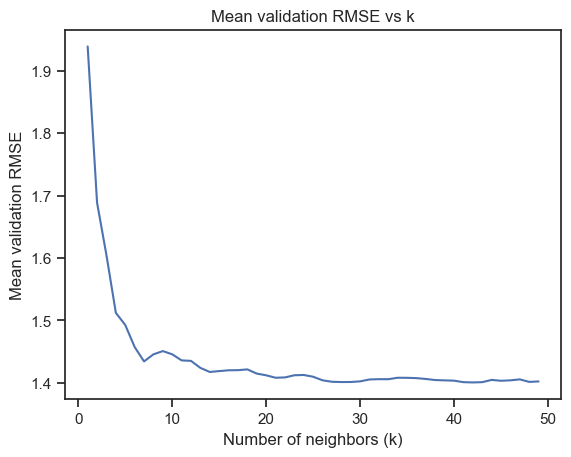

In [98]:
plt.plot(k_values, forest_fires_rmse_scores,)
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Mean validation RMSE')
plt.title('Mean validation RMSE vs k')
plt.show()

In [99]:
## Retraining KNN with best k parameter
forest_fires_best_knn = KNeighborsRegressor(n_neighbors=best_forest_fires_k_knn)
forest_fires_best_knn.fit(forest_fires_X_train, forest_fires_y_train)

## Calculate RMSE on Test set
forest_fires_y_pred = forest_fires_best_knn.predict(forest_fires_X_test)
forest_fires_test_knn_rmse = np.sqrt(mean_squared_error(forest_fires_y_test, forest_fires_y_pred))
print(f'Test RMSE with best k value of {best_forest_fires_k_knn}: {forest_fires_test_knn_rmse:.4f}')

Test RMSE with best k value of 42: 1.3307


In [100]:
## Retaining weighted KNN using distance
forest_fires_knn_weighted = KNeighborsRegressor(n_neighbors=best_forest_fires_k_knn, weights='distance')
forest_fires_knn_weighted.fit(forest_fires_X_train, forest_fires_y_train)

## Calculate accuracy on Test set
forest_fires_weighted_y_pred = forest_fires_knn_weighted.predict(forest_fires_X_test)
forest_fires_test_weighted_knn_rmse = np.sqrt(mean_squared_error(forest_fires_y_test, forest_fires_weighted_y_pred))
print(f'Test RMSE with weighted KNN using distance with best k value of {best_forest_fires_k_knn}: {forest_fires_test_weighted_knn_rmse:.4f}')


Test RMSE with weighted KNN using distance with best k value of 42: 1.3165


#### DT Regression

In [104]:
decision_tree = DecisionTreeRegressor()
param_grid = {'max_depth': range(1, 30)}

forest_fires_grid_search = GridSearchCV(decision_tree, param_grid, cv=cross_val, scoring='neg_root_mean_squared_error')
forest_fires_grid_search.fit(forest_fires_X_train, forest_fires_y_train)

## Best max_depth parameter
best_forest_fires_depth_decisiontree = forest_fires_grid_search.best_params_['max_depth']
best_forest_fires_rmse_dt = -forest_fires_grid_search.best_score_
print(f'Best tree depth parameter: {best_forest_fires_depth_decisiontree}')
print(f'Best RMSE with tree depth of {best_forest_fires_depth_decisiontree}: {best_forest_fires_rmse_dt:.4f}')

Best tree depth parameter: 2
Best RMSE with tree depth of 2: 1.4130


Text(0.5, 1.0, 'Mean RMSE vs max tree depth')

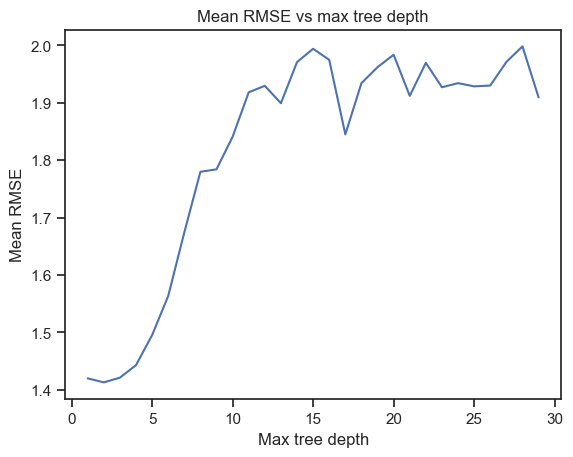

In [107]:
max_depths = range(1, 30)
forest_fires_mean_rmse = -forest_fires_grid_search.cv_results_['mean_test_score']

plt.plot(max_depths, forest_fires_mean_rmse)
plt.xlabel('Max tree depth')
plt.ylabel('Mean RMSE')
plt.title('Mean RMSE vs max tree depth')

In [106]:
# using best max_depth parameter to retrain the DT model
forest_fires_final_tree = DecisionTreeRegressor(max_depth=best_forest_fires_depth_decisiontree)
forest_fires_final_tree.fit(forest_fires_X_train, forest_fires_y_train)

forest_fires_y_pred = forest_fires_final_tree.predict(forest_fires_X_test)
forest_fires_test_decision_rmse = np.sqrt(mean_squared_error(forest_fires_y_test, forest_fires_y_pred))
print(f'Test RMSE: {forest_fires_test_decision_rmse:.4f}')


Test RMSE: 1.3208


#### Random Forest Regression

In [108]:
param_grid = {'n_estimators': range(1, 30), 'max_depth': range(1, 30)}

forest_fires_grid_search_rf = GridSearchCV(RandomForestRegressor(), param_grid, cv=cross_val, scoring='neg_root_mean_squared_error',n_jobs=-1)
forest_fires_grid_search_rf.fit(forest_fires_X_train, forest_fires_y_train)

results = pd.DataFrame(forest_fires_grid_search_rf.cv_results_)

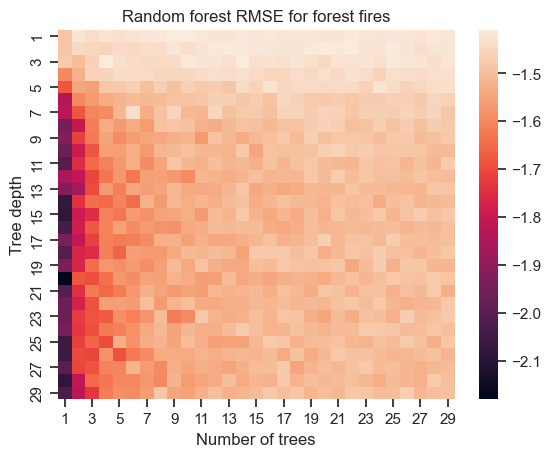

Best tree depth: 3
Best number of trees: 4
Best RMSE: 1.4088774776237831


In [109]:
heat_map_data = results.pivot(index='param_max_depth', columns='param_n_estimators', values='mean_test_score')

sns.heatmap(heat_map_data)
plt.title('Random forest RMSE for forest fires')
plt.xlabel('Number of trees')
plt.ylabel('Tree depth')
plt.show()

# Best parameters
best_forest_fires_depth_forest = forest_fires_grid_search_rf.best_params_['max_depth']
best_forest_fires_n_estimators_forest = forest_fires_grid_search_rf.best_params_['n_estimators']
best_forest_fires_rmse_rf = -forest_fires_grid_search_rf.best_score_
print('Best tree depth:', best_forest_fires_depth_forest)
print('Best number of trees:', best_forest_fires_n_estimators_forest)
print('Best RMSE:', best_forest_fires_rmse_rf)

In [110]:
# retaining the model with best parameters
forest_fires_final_forest = RandomForestRegressor(max_depth=best_forest_fires_depth_forest, n_estimators=best_forest_fires_n_estimators_forest)
forest_fires_final_forest.fit(forest_fires_X_train, forest_fires_y_train)

forest_fires_y_pred = forest_fires_final_forest.predict(forest_fires_X_test)
forest_fires_test_forest_rmse = np.sqrt(mean_squared_error(forest_fires_y_test, forest_fires_y_pred))
print(f'Test RMSE: {forest_fires_test_forest_rmse:.4f}')

Test RMSE: 1.3795


#### Gradient Tree Boosting

In [111]:
param_grid = {'n_estimators': range(1, 30), 'max_depth': range(1, 30)}
forest_fires_grid_search_boost = GridSearchCV(GradientBoostingRegressor(), param_grid, cv=cross_val, scoring='neg_root_mean_squared_error', n_jobs=-1)
forest_fires_grid_search_boost.fit(forest_fires_X_train, forest_fires_y_train)

results = pd.DataFrame(forest_fires_grid_search_boost.cv_results_)

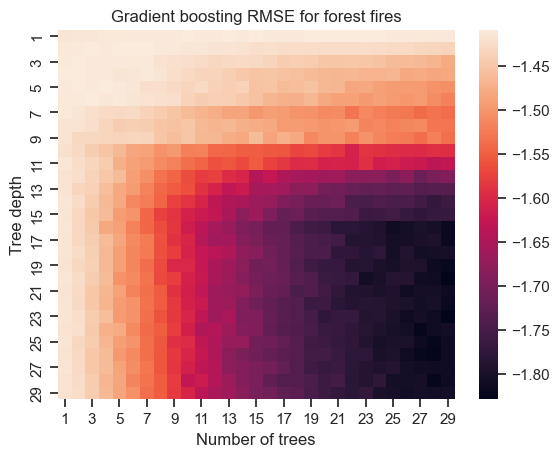

Best tree depth: 1
Best number of trees: 22
Best RMSE: 1.4088059139152946


In [112]:
heat_map_data = results.pivot(index='param_max_depth', columns='param_n_estimators', values='mean_test_score')

sns.heatmap(heat_map_data)
plt.title('Gradient boosting RMSE for forest fires')
plt.xlabel('Number of trees')
plt.ylabel('Tree depth')
plt.show()

## Best parameters
best_forest_fires_depth_boost = forest_fires_grid_search_boost.best_params_['max_depth']
best_forest_fires_n_estimators_boost = forest_fires_grid_search_boost.best_params_['n_estimators']
best_forest_fires_rmse_boost = -forest_fires_grid_search_boost.best_score_
print('Best tree depth:', best_forest_fires_depth_boost)
print('Best number of trees:', best_forest_fires_n_estimators_boost)
print('Best RMSE:', best_forest_fires_rmse_boost)

In [113]:
# using best parameters to retrain the gradient tree boosting model
forest_fires_final_boost = GradientBoostingRegressor(max_depth=best_forest_fires_depth_boost, n_estimators=best_forest_fires_n_estimators_boost)
forest_fires_final_boost.fit(forest_fires_X_train, forest_fires_y_train)

forest_fires_y_pred = forest_fires_final_boost.predict(forest_fires_X_test)
forest_fires_test_boost_rmse = np.sqrt(mean_squared_error(forest_fires_y_test, forest_fires_y_pred))
print(f'Test RMSE: {forest_fires_test_boost_rmse:.4f}')

Test RMSE: 1.3193


In [114]:
# Presenting the results for all models for forest fires dataset sorted from lowest to highest
results = pd.DataFrame({
    'Model': ['KNN', 'Weighted KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Test RMSE': [forest_fires_test_knn_rmse, forest_fires_test_weighted_knn_rmse, forest_fires_test_decision_rmse, forest_fires_test_forest_rmse, forest_fires_test_boost_rmse]
})
results = results.sort_values(by='Test RMSE')
results

,Model,Test RMSE
1,Weighted KNN,1.316451
4,Gradient Boosting,1.319270
2,Decision Tree,1.320751
0,KNN,1.330687
3,Random Forest,1.379539


### Model choice and conclusion
From the above training algorithms, the model produced by Weighted KNN has the best performance when evaluated with Root Mean Square Error as the performance metric as it has the lowest Root Mean Square Error value. 
That being said the Root Mean Square Error of 1.316 is slightly higher than ideal, which might mean that the model is having some difficulty finding a optimal solution to the regression problem.  
This might mean that either there is little correlation from the features provided to the area of the forest fires, or that future data processing is required to more accurately model the area of the fires.